# **GAN의 학습**

**모델 정의 - generator, discriminator, gan**

In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation, LeakyReLU, UpSampling2D, Conv2D
from tensorflow.keras.models import Sequential, Model

import numpy as np
import matplotlib.pyplot as plt

# 생성자 모델 만들기
generator = Sequential()
generator.add(Dense(128*7*7, input_dim=100, activation=LeakyReLU(0.2)))  # 노이즈 벡터 z (100차원) → Dense (완전 연결) 레이어 → 이미지 모양으로 변환하기 전의 feature map
generator.add(BatchNormalization())  # 배치 정규화 적용: 학습 안정성과 수렴 속도 향상을 위해
generator.add(Reshape((7, 7, 128)))  # 벡터 > 이미지 텐서로 변환
generator.add(UpSampling2D())  # 크기를 2배로 업샘플링  (7, 7, 128) → (14, 14, 128)
generator.add(Conv2D(64, kernel_size=5, padding='same'))  # 64개 필터를 적용한 합성곱 층.   (14, 14, 64)
generator.add(BatchNormalization())  # 다시 배치 정규화로 안정화
generator.add(Activation(LeakyReLU(0.2)))
generator.add(UpSampling2D())
generator.add(Conv2D(1, kernel_size=5, padding='same', activation='tanh'))
# 최총 출력층: 흑백이미지이므로 채널 수는 1
# 출력 크기: (28, 28, 1)
# tanh를 사용하는 이유는 보통 이미지 데이터를 [-1, 1] 범위로 정규화하여 학습하기 때문.


# 판별자 모델 만들기
discriminator = Sequential()
discriminator.add(Conv2D(64, kernel_size=5, strides=2, input_shape=(28, 28, 1), padding='same'))
# (28, 28, 1) → (14, 14, 64)
# 이미지 공간 정보는 줄이고 채널(특징 정보)은 늘력서 이미지가 진짜인기 가짜인지 판단할 수 있는 중요 특징을 추출한다.
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3))
discriminator.add(Conv2D(128, kernel_size=5, strides=2, padding='same'))  # (7, 7, 128)
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3))
discriminator.add(Flatten())  # 완전연결층에 넣기 위해 shape 변환: (7, 7, 128) 텐서 → (6272, )
discriminator.add(Dense(1, activation='sigmoid'))  # 이진판별(진짜/가짜) (1, )
# 마지막층: 출력 뉴런1개
# sigmoid 활성화: 출력은 0~1사이 값. 0에 가까우면 가짜, 1에 가까우면 진짜
discriminator.compile(loss='binary_crossentropy', optimizer='adam')
# compile(): 학습준비
# 이진 분류기이므로 손실함수는 이진크로스엔트로피.
discriminator.trainable = False
# generator 학습 시 discriminator를 고정(freeze) 시키는 역할
# 이렇게 해야 generator만 학습되고, discriminator는 그대로 유지된다.


# 생성자-판별자 모델을 연결시키는 GAN모델 만들기
ginput = Input(shape=(100, ))  # generator의 입력인 노이즈 벡터 z 정의
dis_output = discriminator(generator(ginput))
# generator(ginput): 100차원 z를 받아서 이미지 (28, 28, 1)을 생성
# discriminator(...): Generator가 만든 이미지를 판별기에 넣어, 진짜/가짜를 판단. 결과는 0~1 사이 값.
gan = Model(ginput, dis_output)  # 전체 GAN 모델 생성
gan.compile(loss='binary_crossentropy', optimizer='adam')  # 손실함수, 최적화 정의
gan.summary()  # 전체 모델 구조 출력

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │       865,281 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,078,146 (4.11 MB)

 Trainable params: 852,609 (3.25 MB)

 Non-trainable params: 225,537 (881.00 KB)

**함수 정의**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step
epoch:0  d_loss:0.6972  g_loss:0.6854
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
epoch:1  d_loss:0.6966  g_loss:0.6892
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
epoch:2  d_loss:0.6980  g_loss:0.6837
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
epoch:3  d_loss:0.6992  g_loss:0.6833
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
epoch:4  d_loss:0.7004  g_loss:0.6783
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
epoch:5  d_loss:0.7016  g_loss:0.6742
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
epoch:6  d_loss:0.7031  g_loss:0.6698
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
epoch:7  d_loss:0.7046  g_loss:0.6681
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
epoch:8  d_loss:0.7049  g_loss:0.6648
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
epoch:9  d_loss:0.7053  g_loss:0.6623
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
epoch:10  d_loss:0.7059  g_loss:0.6607
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
epoch:11  d_loss:0.7061  g_loss:0.6587
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
epoch:12

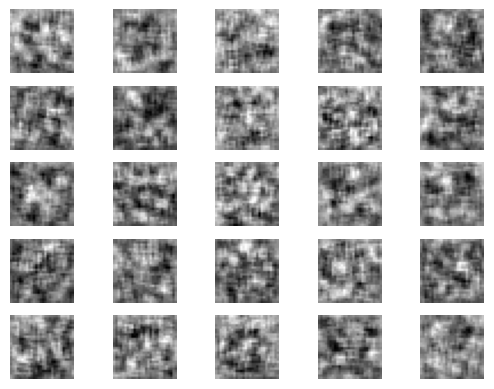

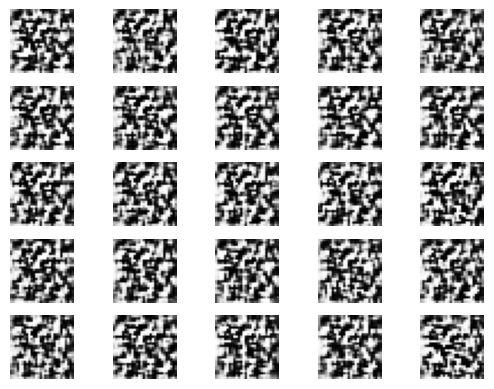

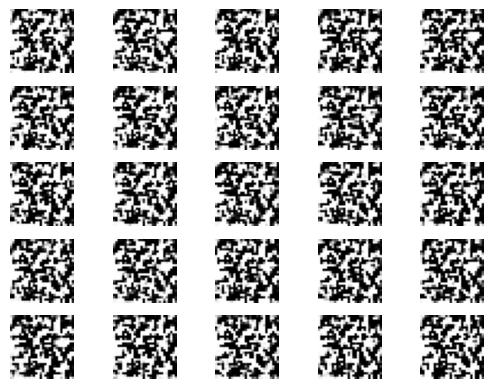

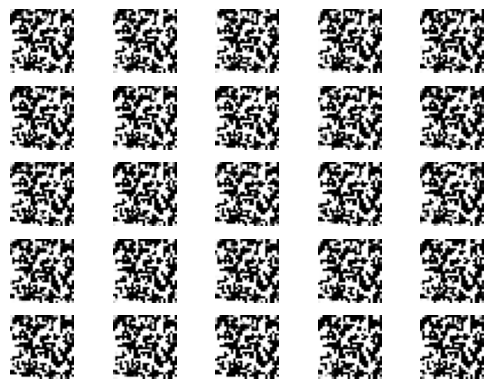

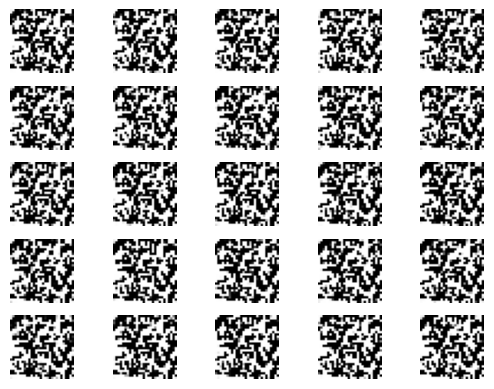

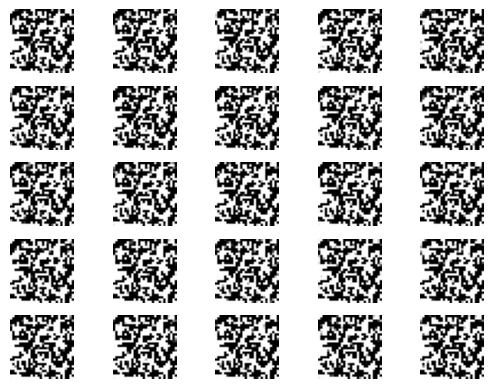

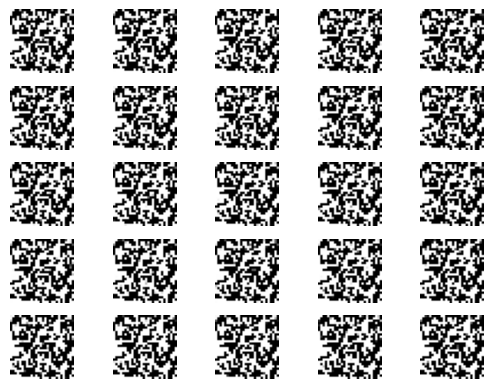

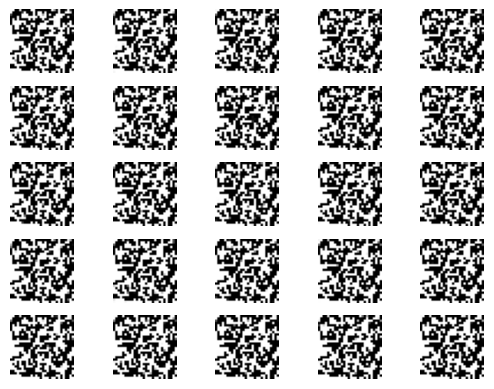

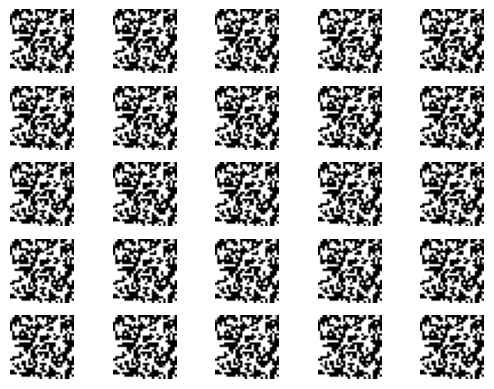

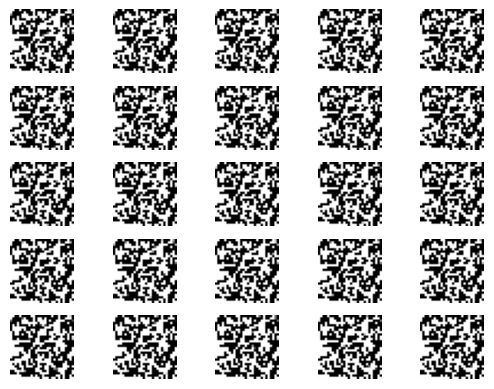

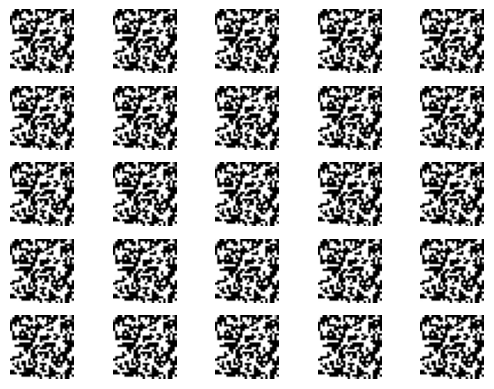

In [2]:
def gan_train(epoch, batch_size, saving_interval):

    (X_train, _), (_, _) = mnist.load_data()  # 테스트 과정은 필요 없고 이미지만 사용할 것이기 때문에 X_train만 불러온다.
    X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
    X_train = (X_train - 127.5) / 127.5
    # 픽셀 값은 0에서 255 사이의 값이다. 이전에 255로 나누어 줄때는 이를 0~1 사이의 값으로 바꾸었던 것인데, 여기서는 127.5를 빼준 뒤 127.5로 나누어 줌으로 인해 -1에서 1사이의 값으로 바뀌게 된다.
    # X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

    true = np.ones((batch_size, 1))  # 실제 이미지 레이블
    fake = np.zeros((batch_size, 1))  # 생성된 이미지 레이블

    for i in range(epoch):
        # 실제 데이터를 판별자에 입력하는 부분
        idx = np.random.randint(0, X_train.shape[0], batch_size)  # X_train에서 무작위로 batch_size만큼의 인덱스를 선택
        imgs = X_train[idx]  # 선택된 인덱스에 해당하는 실제 이미지들 (imgs)을 가져옴.  shape: (batch_size, 28, 28, 1)
        d_loss_real = discriminator.train_on_batch(imgs, true)  # 실제 이미지(imgs)를 Discriminator에 학습시키는 부분

        # 가상 데이터를 판별자에 입력하는 부분
        noise = np.random.normal(0, 1, (batch_size, 100))  # 평균 0, 표준편차 1의 정규분포를 따르는 노이즈 벡터 생성
        gen_imgs = generator.predict(noise)  # Generator를 통해 가짜 이미지 생성
        d_loss_fake = discriminator.train_on_batch(gen_imgs, fake)

        # 판별자와 생성자의 오차 계산
        d_loss = 0.5*np.add(d_loss_real, d_loss_fake)  # 실제 + 가짜 이미지에 대한 판별자의 평균 손실
        g_loss = gan.train_on_batch(noise, true)  # 생성자 학습(판별자를 속이도록)

        # train_on_batch() 결과가 리스트이면 첫 번째 값 사용
        if isinstance(d_loss, list):
            d_loss = d_loss[0]
        if isinstance(g_loss, list):
            g_loss = g_loss[0]

        print('epoch:%d' % i, ' d_loss:%.4f' % d_loss, ' g_loss:%.4f' % g_loss)


        # 중간 과정을 이미지로 저장. 이미지들은 gan_images 폴더에 저장된다.
        if i % saving_interval == 0:
            # 1. 노이즈 벡터 생성 (25개, z 크기=100)
            noise = np.random.normal(0, 1, (25, 100))
            gen_imgs = generator.predict(noise)

            # 2. 이미지 스케일 조정 (-1~1 → 0~1) : 시각화를 위해 [0, 1]로 변환
            gen_imgs = 0.5 * gen_imgs + 0.5

            # 3. 5x5 그림판에 이미지 배치
            fig, axs = plt.subplots(5, 5)
            count = 0
            for j in range(5):
                for k in range(5):
                    axs[j, k].imshow(gen_imgs[count, :, :, 0], cmap='gray')
                    axs[j, k].axis('off')
                    count += 1

            # 4. 파일로 저장
            fig.savefig("./gan_mnist_%d.png" % i)

gan_train(2001, 32, 200)

# **DCGAN**

In [3]:
import random
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils
import torch.nn as nn
import torch.optim as optim
import matplotlib.animation as animation
from IPython.display import HTML
from torchvision.datasets import Food101
from torchvision.transforms import v2

In [4]:
manualSeed = 2025
random.seed(manualSeed)
torch.manual_seed(manualSeed)
# 같은 입력과 같은 코드를 항상 동일한 출력
torch.use_deterministic_algorithms(True)

In [5]:
image_size = 64
dataset = Food101(root=".", split="train", download=True,
                  transform=v2.Compose([
                      v2.ToImage(),
                      v2.Resize((image_size, image_size), antialias=True),  # antialias: 계단현상 최소화
                      v2.ToDtype(torch.float32, scale=True),
                      v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                  ]))

100%|██████████| 5.00G/5.00G [04:39<00:00, 17.8MB/s]


In [6]:
workers = 2
batch_size = 128
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

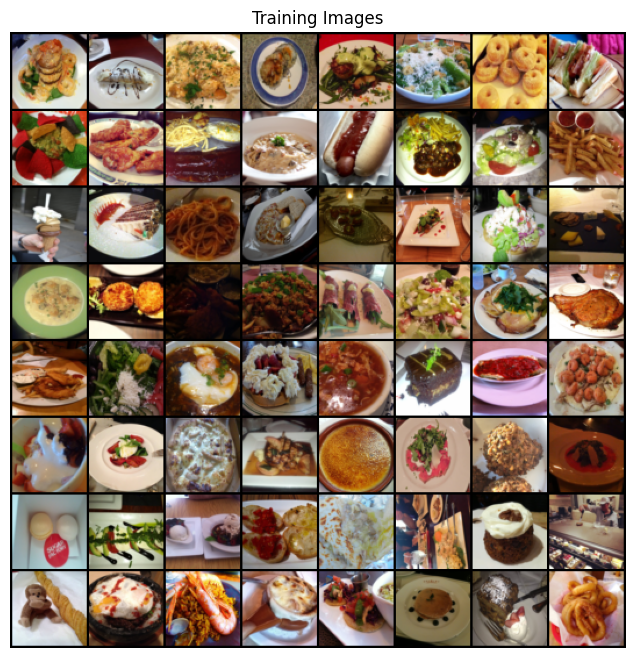

In [7]:
real_batch = next(iter(dataloader))
# 즉, real_batch는 이미지다.
# dataloader는 학습용 이미지 데이터를 가져오는 PyTorch의 데이터로더.
#iter()로 반복자를 만들고, next()로 첫 번째 배치(예: 64장 이미지)를 꺼내온다.
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0][:64], padding=2, normalize=True),(1,2,0)))
# real_batch[0]: 배치 안에서 이미지 텐서만 선택한 것입니다. (레이블 등은 무시)
# PyTorch 이미지 텐서: (채널, 높이, 너비)
# matplotlib: (높이, 너비, 채널)

In [8]:
# 초기 가중치(weight)를 설정

def weights_init(m):  # m: 모델의 각 층(layer)
    classname = m.__class__.__name__  # 현재 층의 클래스 이름(예: Conv2d, BatchNorm2d)을 문자열로 저장
    if classname.find('Conv') != -1:
        #  Conv라는 단어가 이름에 포함되어 있다면, 즉 합성곱(Convolutional) 계층이면:
        # 중치를 평균 0.0, 표준편차 0.02인 **정규분포(노멀분포)**로 초기화
        # 가중치를 평균:0, 표준편차: 0.02에 맞춰라 (DCGAN 논문에서 추천한 초기화 방법)
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        # 배치 정규화(Batch Normalization) 계층일 경우: 평균 1, 표준편차 0, 바이어스 0 으로
    elif classname.find('BatchNorm') != -1:
        # 가중치를 스케일 파라미터 y: 1, bias: 0
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.normal_(m.bias.data, 0)


# 이걸 하는 이유
#딥러닝에서는 가중치 초기화가 모델의 성능과 학습 안정성에 큰 영향을 줍니다.
# 특히 GAN에서는 훈련이 불안정할 수 있기 때문에, 이런 정교한 초기화 방법이 필요합니다.

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [10]:
nc = 3     # 출력 이미지 채널 수
ngf = 64  # 기본 채널 크기
nz = 100  # 잠재벡터(노이즈) 차원 (batch, nz, 1, 1)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
           # input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),   # 4: 커널사이즈, 2: 스트라이드, 0: 패딩
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),
            # state size. ``(ngf*8) x 4 x 4``

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),
            # state size. ``(ngf*4) x 8 x 8``

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            # state size. ``(ngf*2) x 16 x 16``

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. ``(ngf) x 32 x 32``

           nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
           nn.Tanh()
           # state size. ``(nc) x 64 x 64``
        )


    def forward(self, input):
        return self.main(input)

In [11]:
ndf = 64

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is ``(nc) x 64 x 64``
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf) x 32 x 32``

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*2) x 16 x 16``

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*4) x 8 x 8``

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*8) x 4 x 4``

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)


# 이미지를 입력으로 받아서,
# 진짜인지 가짜(생성된 이미지)인지 판별하는 역할을 해요.
# 결과는 0~1 사이의 값으로 나옵니다 (0은 가짜, 1은 진짜에 가까움).

In [12]:
netG = Generator().to(device)
netD = Discriminator().to(device)

In [13]:
netG

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [14]:
netD

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [15]:
netG.apply(weights_init)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [16]:
criterion = nn.BCELoss()

fixed_noise = torch.randn(64, nz, 1, 1, device=device)

real_label = 1.
fake_label = 0.

lr = 0.0002
beta1 = 0.5
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [17]:
img_list = []
G_losses = []
D_losses = []
iters = 0

num_epochs = 5

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        ###################
        netD.zero_grad()

        real = data[0].to(device)
        b_size = real.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output = netD(real).view(-1)

        errD_real = criterion(output, label)

        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, nz, 1, 1, device=device)

        fake = netG(noise)
        label.fill_(fake_label)

        output = netD(fake.detach()).view(-1)

        errD_fake = criterion(output, label)

        errD_fake.backward()
        D_G_z1 = output.mean().item()

        errD = errD_real + errD_fake

        optimizerD.step()
        ###################
        netG.zero_grad()
        label.fill_(real_label)

        output = netD(fake).view(-1)

        errG = criterion(output, label)

        errG.backward()
        D_G_z2 = output.mean().item()

        optimizerG.step()
        ###################

        # Loss_D: 낮을수록 잘 구분,  Loss_G: 낮을수록 잘 속임
        # D(x): real이미지를 얼마나 진짜로 보는지, D(G(z)): 업데이트 전 가짜 평균 / 업데이트 후 가짜 평균
        if i % 50 == 0:
            print(f"[{epoch}/{num_epochs}] [{i}/{len(dataloader)}]\tLoss_D: {errD.item():.4f}\tLoss_G: {errG.item():.4f}\tD(x): {D_x:.4f}\tD(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}")


        G_losses.append(errG.item())
        D_losses.append(errD.item())


        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

[0/5] [0/592]	Loss_D: 1.6678	Loss_G: 6.7344	D(x): 0.4113	D(G(z)): 0.4371 / 0.0015
[0/5] [50/592]	Loss_D: 0.3185	Loss_G: 12.9166	D(x): 0.7674	D(G(z)): 0.0000 / 0.0000
[0/5] [100/592]	Loss_D: 0.0926	Loss_G: 5.5756	D(x): 0.9442	D(G(z)): 0.0026 / 0.0054
[0/5] [150/592]	Loss_D: 0.4372	Loss_G: 8.0106	D(x): 0.9692	D(G(z)): 0.3236 / 0.0004
[0/5] [200/592]	Loss_D: 0.9966	Loss_G: 6.8978	D(x): 0.5367	D(G(z)): 0.0013 / 0.0012
[0/5] [250/592]	Loss_D: 0.2782	Loss_G: 4.6544	D(x): 0.9402	D(G(z)): 0.1805 / 0.0127
[0/5] [300/592]	Loss_D: 0.7987	Loss_G: 6.2293	D(x): 0.9035	D(G(z)): 0.4594 / 0.0031
[0/5] [350/592]	Loss_D: 0.3700	Loss_G: 3.9535	D(x): 0.7995	D(G(z)): 0.0887 / 0.0262
[0/5] [400/592]	Loss_D: 0.2637	Loss_G: 4.2961	D(x): 0.9198	D(G(z)): 0.1543 / 0.0178
[0/5] [450/592]	Loss_D: 0.3555	Loss_G: 4.7102	D(x): 0.9388	D(G(z)): 0.2290 / 0.0122
[0/5] [500/592]	Loss_D: 0.4734	Loss_G: 3.3241	D(x): 0.8457	D(G(z)): 0.2216 / 0.0472
[0/5] [550/592]	Loss_D: 0.7161	Loss_G: 3.4836	D(x): 0.8073	D(G(z)): 0.3430 / 0

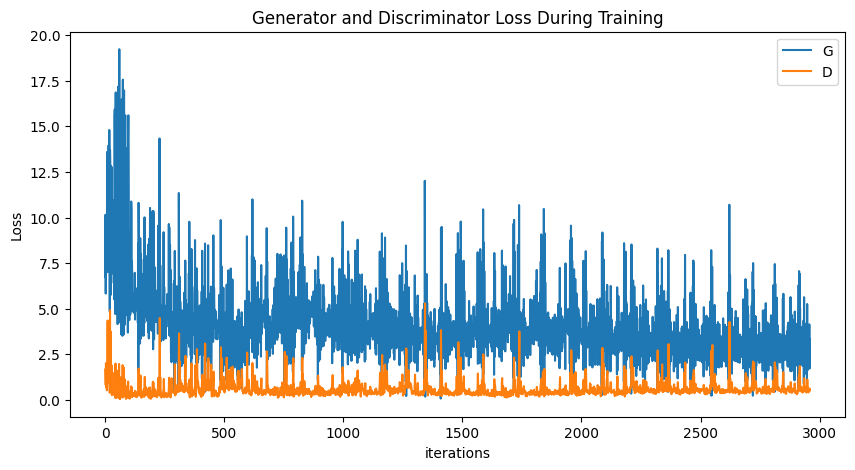

In [18]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
fig = plt.figure(figsize=(8,8))
plt.axis("off")
ims = [[plt.imshow(np.transpose(i,(1,2,0)), animated=True)] for i in img_list]
ani = animation.ArtistAnimation(fig, ims, interval=1000, repeat_delay=1000, blit=True)

HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

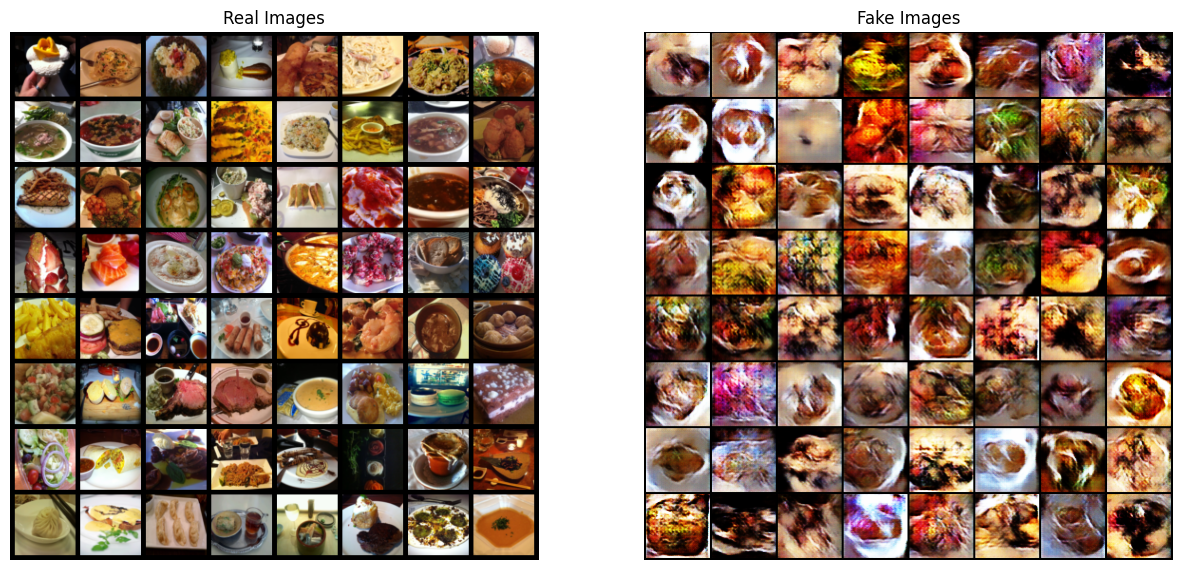

In [20]:
real_batch = next(iter(dataloader))

plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()